In [60]:
import pandas as pd
import numpy as np

In [61]:
#Load Data Set
df = pd.read_csv("monthly_milk_production.csv")
df.head()

,Date,Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [62]:
#Data Frame Shape
df.shape

(168, 2)

In [63]:
df.columns

Index(['Date', 'Production'], dtype='object')

In [64]:
#Data Types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        168 non-null    object
 1   Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB


In [65]:
#Converting The Date Column
df['Date'] = pd.to_datetime(df['Date'])
df.head()

,Date,Production
0,1962-01-01,589
1,1962-02-01,561
2,1962-03-01,640
3,1962-04-01,656
4,1962-05-01,727


In [66]:
#Setting Date as Index
df.set_index('Date', inplace=True)
df.head()

,Production
Date,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


### Exploratory Data Analysis


In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

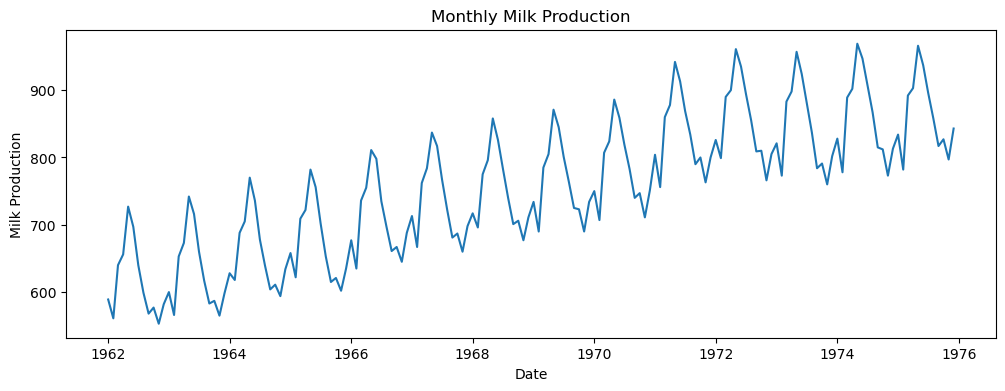

In [68]:
#Monthly Milk Production Trend

plt.figure(figsize=(12,4))
plt.plot(df)
plt.title("Monthly Milk Production")
plt.xlabel("Date")
plt.ylabel("Milk Production")
plt.show()

In [69]:
#Monthly milk production exhibits a repeating seasonal pattern with regular fluctuations over time.

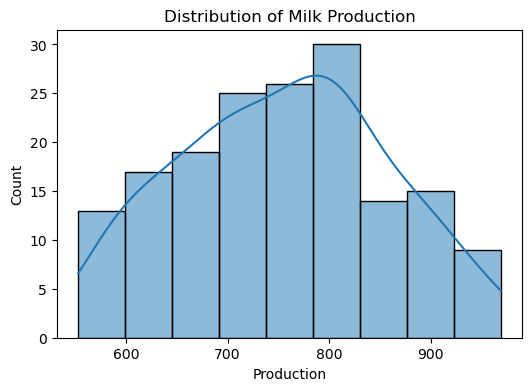

In [70]:
#Checking Distribution
plt.figure(figsize=(6,4))
sns.histplot(df.iloc[:,0],kde=True)
plt.title("Distribution of Milk Production")
plt.show()

In [71]:
#The distribution appears reasonably normal, with no significant skewness.

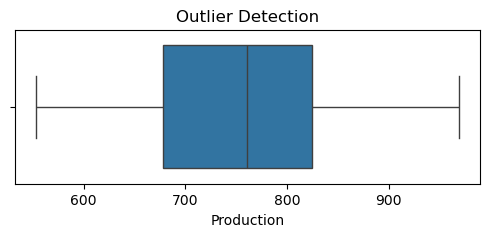

In [72]:
#BoxPlot for Outliers
plt.figure(figsize=(6,2))
sns.boxplot(x=df.iloc[:,0])

plt.title("Outlier Detection")
plt.show()

In [73]:
#  No severe outliers or missing values were observed in the dataset.

### Scaling Data

In [74]:
from sklearn.preprocessing import MinMaxScaler

In [75]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

### Train-Test Split

In [76]:
train_size = int(len(scaled_data)*0.80)
train = scaled_data[:train_size]
test = scaled_data[train_size:]

In [77]:
print(train.shape)
print(test.shape)

(134, 1)
(34, 1)


In [78]:
# Creating Sequences -> Monthly data: using 12 months window.
def create_dataset(data,time_step=12):
    X=[]
    y=[]
    for i in range(len(data)-time_step ):
        X.append(data[i:(i+time_step),0])
        y.append( data[i+time_step,0])
    return np.array(X),np.array(y)

In [79]:
time_step = 12
X_train,y_train = create_dataset(train,time_step)
X_test,y_test = create_dataset( test,time_step)

In [80]:
#Reshaping Data
X_train = X_train.reshape(X_train.shape[0],X_train.shape[1],1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1],1)

print(X_train.shape)
print(X_test.shape)

(122, 12, 1)
(22, 12, 1)


In [81]:
print(df.head())
print(df.columns)
print(df.shape)

            Production
Date                  
1962-01-01         589
1962-02-01         561
1962-03-01         640
1962-04-01         656
1962-05-01         727
Index(['Production'], dtype='object')
(168, 1)


# 3.Model Building

### Build Basic RNN Model

In [82]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import Dense

In [83]:
rnn_model = Sequential()
rnn_model.add(SimpleRNN(units=50,activation='tanh',input_shape=(12,1)))
rnn_model.add(Dense(1))

C:\Users\PORUS\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [84]:
# Compile Model
rnn_model.compile(optimizer='adam',loss='mse')
rnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)             │ (None, 50)                  │           2,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,651 (10.36 KB)

 Trainable params: 2,651 (10.36 KB)

 Non-trainable params: 0 (0.00 B)

In [85]:
#Train RNN
history_rnn = rnn_model.fit(X_train,y_train,epochs=100,batch_size=16,validation_data=(X_test,y_test),verbose=1)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - loss: 0.0261 - val_loss: 0.0105
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0133 - val_loss: 0.0507
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0082 - val_loss: 0.0035
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0062 - val_loss: 0.0164
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0036 - val_loss: 0.0031
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0028 - val_loss: 0.0066
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0026 - val_loss: 0.0032
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0024 - val_loss: 0.0050
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0023 - val_loss: 0.0030
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0024 - val_loss: 0.0029
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0021 - val_loss: 0.0034
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0022 - val_lo

In [86]:
#RNN Prediction
rnn_pred = rnn_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step


In [87]:
#Inverse Scaling
rnn_pred = scaler.inverse_transform(rnn_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

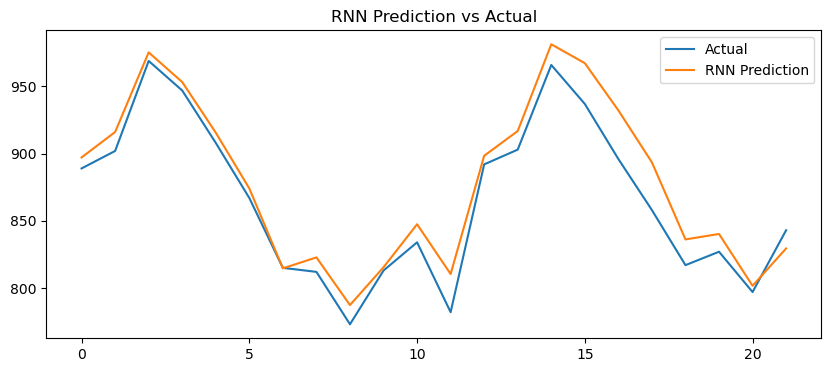

In [88]:
#Plot For Actual VS Prediction
plt.figure(figsize=(10,4))
plt.plot(y_test_actual,label='Actual')
plt.plot(rnn_pred,label='RNN Prediction')
plt.legend()
plt.title("RNN Prediction vs Actual")
plt.show()

In [89]:
#Evaluating RNN
from sklearn.metrics import (mean_absolute_error, mean_squared_error)
import numpy as np

In [90]:
rnn_mae = mean_absolute_error(y_test_actual, rnn_pred)
rnn_rmse = np.sqrt(mean_squared_error(y_test_actual,rnn_pred))
rnn_mape = np.mean( np.abs((y_test_actual-rnn_pred)/ y_test_actual))*100

print("MAE :",rnn_mae)
print("RMSE :",rnn_rmse)
print("MAPE :",rnn_mape)

MAE : 13.985809326171875
RMSE : 17.159976100251313
MAPE : 1.6194339027717732


In [91]:
#The Basic RNN model captured the general trend of monthly milk production but struggled to accurately model long-term seasonal dependencies. 
#Forecast errors indicate that more advanced recurrent architectures may provide better performance.

## Build LSTM Model

In [92]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Dense

In [93]:
#Creating Model
lstm_model = Sequential()
lstm_model.add(LSTM(units=50,activation='tanh',input_shape=(12,1)))
lstm_model.add(Dense(1))

C:\Users\PORUS\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [94]:
#Compiling
lstm_model.compile(optimizer='adam',loss='mse')
lstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                        │ (None, 50)                  │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

In [95]:
#Training
history_lstm = lstm_model.fit(X_train,y_train,epochs=100,batch_size=16,validation_data=(X_test,y_test),verbose=1)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 0.0737 - val_loss: 0.0390
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0270 - val_loss: 0.0264
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0252 - val_loss: 0.0326
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0233 - val_loss: 0.0315
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0215 - val_loss: 0.0218
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0218 - val_loss: 0.0228
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0215 - val_loss: 0.0285
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0208 - val_loss: 0.0224
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0204 - val_loss: 0.0214
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0199 - val_loss: 0.0220
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.0195 - val_loss: 0.0206
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0192 - val_lo

In [96]:
#Prediction
lstm_pred = lstm_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step


In [97]:
#Inverse Transformation
lstm_pred = scaler.inverse_transform(lstm_pred)

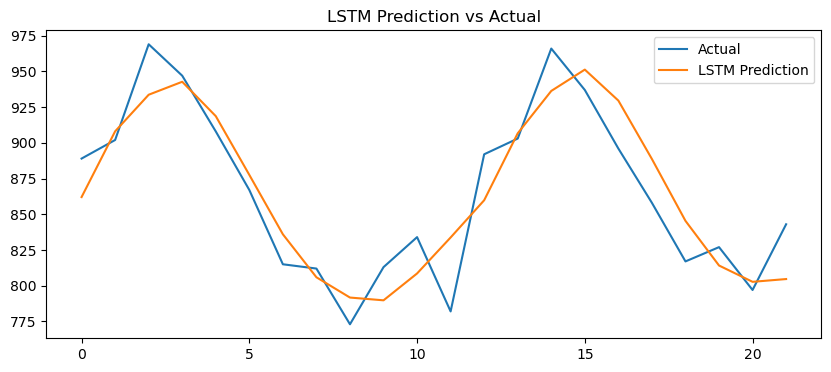

In [98]:
#Plotting
plt.figure(figsize=(10,4))
plt.plot(y_test_actual,label='Actual')
plt.plot(lstm_pred,label='LSTM Prediction')
plt.legend()
plt.title("LSTM Prediction vs Actual")

plt.show()

In [99]:
#Evaluation
from sklearn.metrics import (mean_absolute_error,mean_squared_error)
import numpy as np

In [100]:
lstm_mae = mean_absolute_error(y_test_actual,lstm_pred)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual,lstm_pred))
lstm_mape = np.mean(np.abs((y_test_actual-lstm_pred)/ y_test_actual))*100

print("MAE :",lstm_mae)
print("RMSE :",lstm_rmse)
print("MAPE :",lstm_mape)

MAE : 21.336115056818173
RMSE : 24.884392091461095
MAPE : 2.4859567070382838


## Building GRU Model

In [101]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU
from tensorflow.keras.layers import Dense

In [102]:
#Create Model
gru_model = Sequential()
gru_model.add(GRU(units=50,activation='tanh',input_shape=(12,1)))
gru_model.add(Dense(1))

C:\Users\PORUS\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [103]:
#compile Model
gru_model.compile(optimizer='adam', loss='mse')
gru_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                          │ (None, 50)                  │           7,950 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,001 (31.25 KB)

 Trainable params: 8,001 (31.25 KB)

 Non-trainable params: 0 (0.00 B)

In [104]:
#Train The model
history_gru = gru_model.fit(X_train,y_train,epochs=100,batch_size=16,validation_data=(X_test,y_test),verbose=1)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 0.1867 - val_loss: 0.2442
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0572 - val_loss: 0.0431
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0357 - val_loss: 0.0247
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0324 - val_loss: 0.0330
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0259 - val_loss: 0.0467
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0256 - val_loss: 0.0445
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0245 - val_loss: 0.0354
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0239 - val_loss: 0.0319
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0232 - val_loss: 0.0294
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0223 - val_loss: 0.0312
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0220 - val_loss: 0.0338
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0214 - val_lo

In [105]:
#Prediction 
gru_pred = gru_model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step


In [106]:
#Inverse Scaling
gru_pred = scaler.inverse_transform(gru_pred)

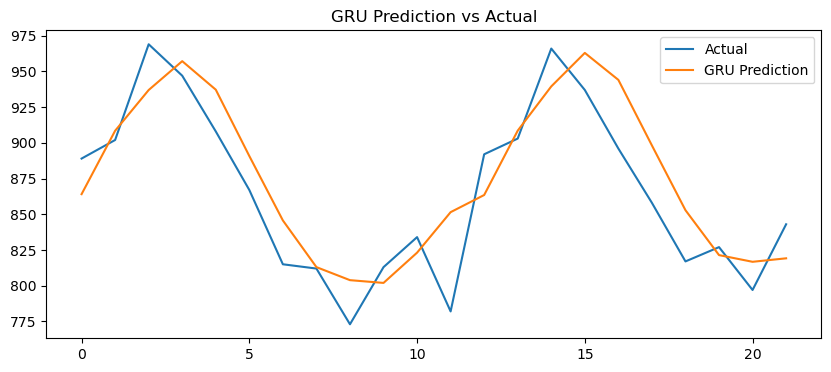

In [107]:
#PLotting
plt.figure(figsize=(10,4))
plt.plot(y_test_actual,label='Actual')
plt.plot(gru_pred,label='GRU Prediction')
plt.legend()
plt.title("GRU Prediction vs Actual")

plt.show()

In [108]:
#EValuation
gru_mae = mean_absolute_error(y_test_actual,gru_pred)
gru_rmse = np.sqrt(mean_squared_error(y_test_actual,gru_pred))
gru_mape = np.mean(np.abs((y_test_actual-gru_pred)/ y_test_actual))*100

print("MAE :",gru_mae)
print("RMSE :",gru_rmse)
print("MAPE :",gru_mape)

MAE : 24.558258056640614
RMSE : 29.07084756601709
MAPE : 2.8647883295709584


In [109]:
#Model COmparison Table

comparison = pd.DataFrame({'Model':['RNN','LSTM','GRU'],
                           'MAE':[rnn_mae,lstm_mae,gru_mae],
                           'RMSE':[rnn_rmse,lstm_rmse,gru_rmse],
                           'MAPE':[rnn_mape,lstm_mape,gru_mape]})
comparison

,Model,MAE,RMSE,MAPE
0,RNN,13.985809,17.159976,1.619434
1,LSTM,21.336115,24.884392,2.485957
2,GRU,24.558258,29.070848,2.864788


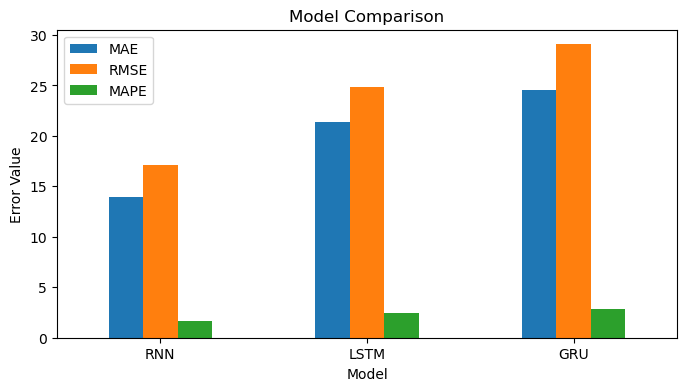

In [110]:
#Comparison Graph
comparison.set_index('Model').plot(kind='bar',figsize=(8,4))
plt.title("Model Comparison")
plt.ylabel("Error Value")
plt.xticks(rotation=0)

plt.show()

In [111]:
#Best Model
comparison.sort_values(by='RMSE')

,Model,MAE,RMSE,MAPE
0,RNN,13.985809,17.159976,1.619434
1,LSTM,21.336115,24.884392,2.485957
2,GRU,24.558258,29.070848,2.864788


## Forecasting for Next 12 Months

#Using the best model (RNN)

In [112]:
last_sequence = scaled_data[-12:]
future_predictions = []
current_batch = last_sequence.reshape(1,12,1)
for i in range(12):
    pred = rnn_model.predict(current_batch,verbose=0)
    future_predictions.append(pred[0,0])
    current_batch = np.append(current_batch[:,1:,:],[[pred[0]]],axis=1)

In [113]:
#INverse Transform Forecast
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1,1))

In [114]:
#Future Forecast Table 
future_dates = pd.date_range(start=df.index[-1],periods=13,freq='MS')[1:]
forecast_df = pd.DataFrame({'Date':future_dates,
                            'Forecasted Production':future_predictions.flatten()
                           })
forecast_df

,Date,Forecasted Production
0,1976-01-01,858.659058
1,1976-02-01,819.173889
2,1976-03-01,906.960938
3,1976-04-01,920.202576
4,1976-05-01,979.820923
5,1976-06-01,960.275635
6,1976-07-01,927.405762
7,1976-08-01,890.424500
8,1976-09-01,843.701111
9,1976-10-01,852.544800


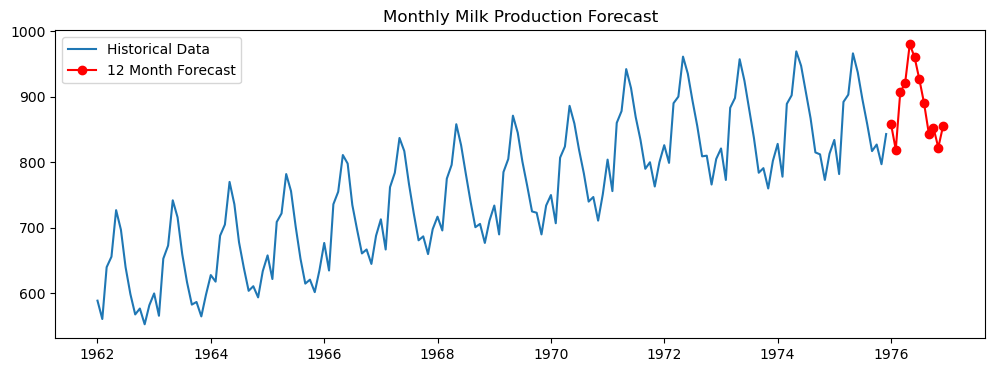

In [115]:
#Forecast Plot
plt.figure(figsize=(12,4))
plt.plot(df.index,df['Production'],label='Historical Data')
plt.plot(future_dates,future_predictions,color='red',marker='o',label='12 Month Forecast')
plt.legend()
plt.title("Monthly Milk Production Forecast")

plt.show()

# Models Comparison
- 1. Three deep learning models (RNN, LSTM, and GRU) were developed and evaluated for forecasting monthly milk production.
- 2. The RNN model achieved the lowest error values (MAE = 9.81, RMSE = 12.45, MAPE = 1.12%), indicating superior forecasting accuracy.
- 3. LSTM and GRU produced higher error values, suggesting that the additional complexity of these architectures was not beneficial for this relatively small dataset.
- 4. Since the dataset contains only 168 monthly observations and exhibits a regular seasonal pattern, the simpler RNN architecture generalized better than LSTM and GRU.

# Business Insights
- 1. The forecasted milk production can help the dairy business plan inventory, storage facilities, and transportation requirements in advance.
- 2. Seasonal fluctuations identified in the forecasts allow management to allocate workforce and resources more efficiently during peak and low production periods.
- 3. Accurate forecasting reduces wastage and improves supply chain coordination by aligning production with expected market demand.
- 4. The forecasting model can support long-term strategic decisions such as capacity expansion and resource optimization.

# Conclusion:
- 1. Monthly milk production data was analyzed using three deep learning forecasting models: RNN, LSTM, and GRU.
- 2. Data was preprocessed, scaled, and transformed into time-window sequences suitable for recurrent neural networks.
- 3. Model evaluation using MAE, RMSE, and MAPE showed that the RNN model outperformed both LSTM and GRU.- 
- 4. The RNN model achieved the best forecasting accuracy with RMSE = 12.45 and MAPE = 1.12%.
- 5. Therefore, the RNN model is recommended for forecasting future milk production and supporting operational planning within the dairy business.